<a href="https://colab.research.google.com/github/Saranya546/ai-interview-agent/blob/main/ML_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resources

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle

In [ ]:
import json
import os

kaggle_info = {
    "username": "bulusulakshmisaranya",
    "key": "KGAT_be7791083edf55b6656fd0c55ca86739"
}

# Create the .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle/', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(kaggle_info, file)

In [ ]:
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d rohitsahoo/sales-forecasting

Dataset URL: https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting
License(s): GPL-2.0
100% 480k/480k [00:00<00:00, 100MB/s]



In [ ]:
!unzip sales-forecasting.zip

Archive:  sales-forecasting.zip
  inflating: train.csv               


In [ ]:
import zipfile

zip_path = "/content/sales-forecasting.zip"   # change your zip name

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print(zip_ref.namelist())

['train.csv']


In [ ]:
!ls

sales-forecasting.zip  sample_data  train.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv('/content/train.csv')
# -----------------------------
# 3. Basic Information
# -----------------------------
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer

In [ ]:
# -----------------------------
# 4. Missing Values
# -----------------------------
print("\nMissing Values:")
print(df.isnull().sum())




Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [ ]:
# -----------------------------
# 5. Duplicate Values
# -----------------------------
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [ ]:
# -----------------------------
# 6. Convert Date Column
# -----------------------------
# Change column name if needed

# Check if 'Order Date' column exists as it was identified in df.info()
if 'Order Date' in df.columns:
    # Convert 'Order Date' to datetime if it's not already
    if not pd.api.types.is_datetime64_any_dtype(df['Order Date']):
        df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y') # Assuming dd/mm/yyyy format based on df.head()

    df['Year'] = df['Order Date'].dt.year
    df['Month'] = df['Order Date'].dt.month
    df['Day'] = df['Order Date'].dt.day

# The original code blocks for 'date' and 'Date' are removed or commented out
# as 'Order Date' is the identified column from df.info()
# elif 'date' in df.columns:
#     df['date'] = pd.to_datetime(df['date'])
#     df['Year'] = df['date'].dt.year
#     df['Month'] = df['date'].dt.month
#     df['Day'] = df['date'].dt.day
# elif 'Date' in df.columns:
#     df['Date'] = pd.to_datetime(df['Date'])
#     df['Year'] = df['Date'].dt.year
#     df['Month'] = df['Date'].dt.month
#     df['Day'] = df['Date'].dt.day

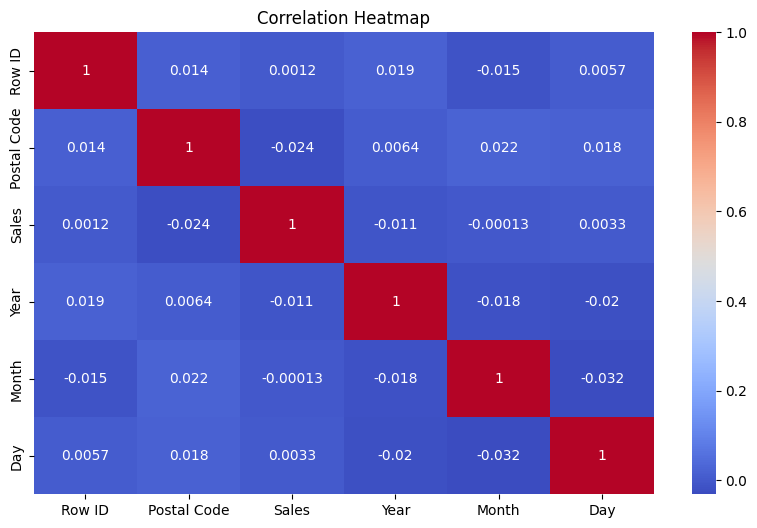

In [ ]:
# -----------------------------
# 7. Correlation Heatmap
# -----------------------------
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

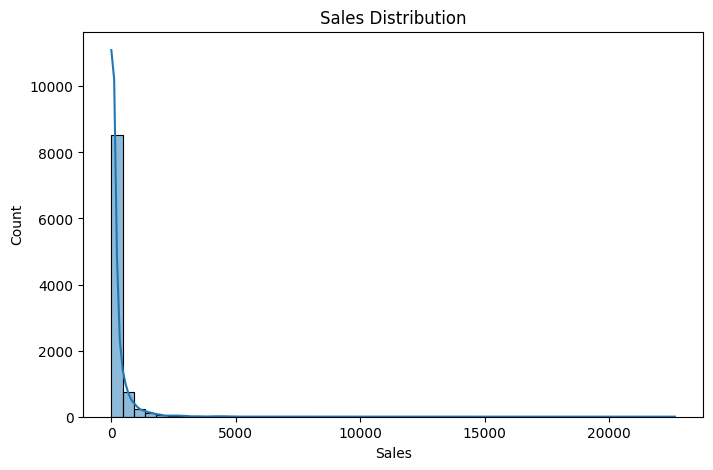

In [ ]:
# -----------------------------
# 8. Target Variable Distribution
# -----------------------------
# Common target columns:
# sales, Sales, item_cnt_day

target_col = None

possible_targets = ['sales', 'Sales', 'item_cnt_day']

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break
# # convert target into dataframe
# df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
# # print the contents of target _col using info
# print(df[target_col].info())
# target_col=Sales

if target_col:
    plt.figure(figsize=(8,5))

    sns.histplot(df[target_col], bins=50, kde=True)

    plt.title(f"{target_col} Distribution")
    plt.show()

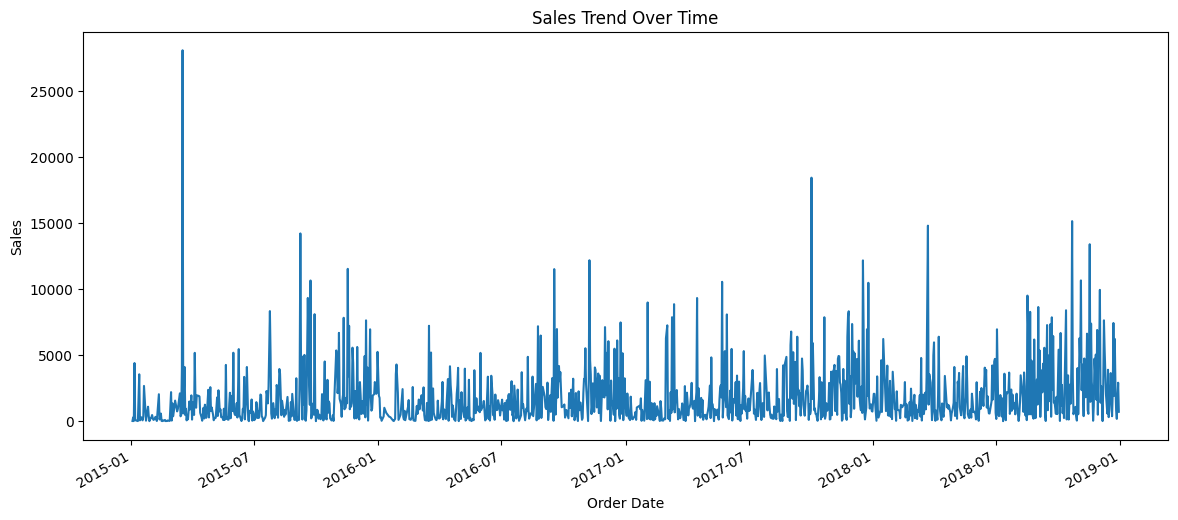

In [ ]:
# -----------------------------
# 9. Time Series Trend
# -----------------------------
if target_col:
    # Check for 'Order Date' and convert if necessary
    if 'Order Date' in df.columns:
        # Convert 'Order Date' to datetime if it's not already
        if not pd.api.types.is_datetime64_any_dtype(df['Order Date']):
            df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y') # Assuming dd/mm/yyyy format based on df.head()

        sales_trend = df.groupby('Order Date')[target_col].sum()

        plt.figure(figsize=(14,6))
        sales_trend.plot()
        plt.title(f"{target_col} Trend Over Time")
        plt.ylabel(target_col)
        plt.xlabel("Order Date") # Add x-label for clarity
        plt.show()
    else:
        print("Error: 'Order Date' column not found for time series trend analysis.")
else:
    print("Error: Target column not defined for time series trend analysis.")


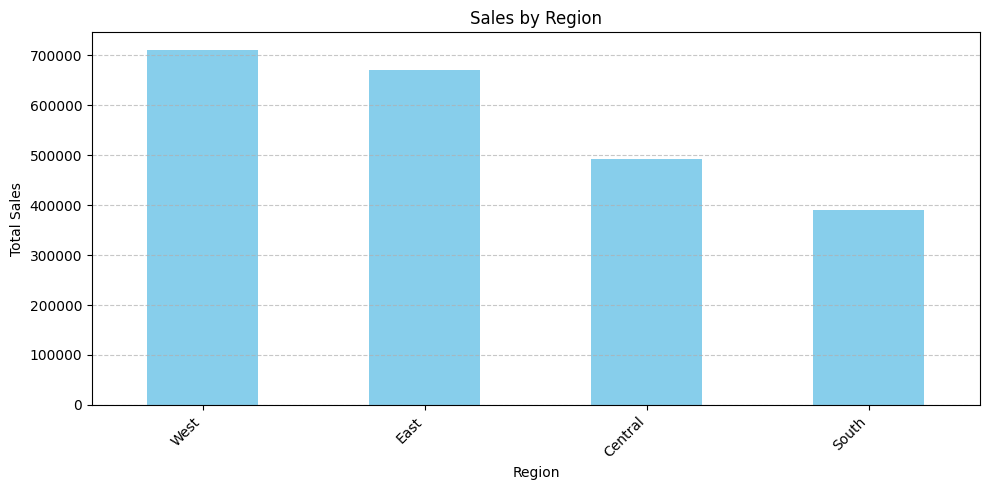

In [ ]:
# -----------------------------
# 10. Sales by Region
# -----------------------------
# Check if 'Region' column exists and target_col is defined
if 'Region' in df.columns and target_col:

    sales_by_region = df.groupby('Region')[target_col].sum().sort_values(ascending=False)

    plt.figure(figsize=(10,5))

    sales_by_region.plot(kind='bar', color='skyblue')

    plt.title("Sales by Region")
    plt.xlabel("Region")
    plt.ylabel(f"Total {target_col}")
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
else:
    print("Error: 'Region' column not found or target_col is not defined for sales by region analysis.")

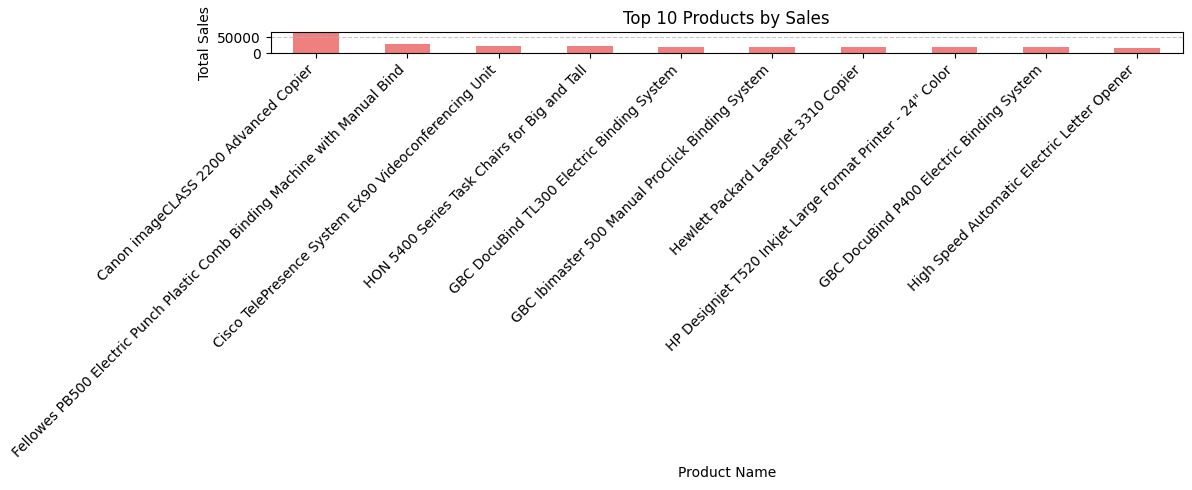

In [ ]:
# -----------------------------
# 11. Top Items by Sales
# -----------------------------
# Check if 'Product Name' column exists and target_col is defined
if 'Product Name' in df.columns and target_col:

    top_items = (
        df.groupby('Product Name')[target_col]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,5))

    top_items.plot(kind='bar', color='lightcoral') # Added color for better visualization

    plt.title("Top 10 Products by Sales")
    plt.xlabel("Product Name")
    plt.ylabel(f"Total {target_col}")
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
else:
    print("Error: 'Product Name' column not found or target_col is not defined for top items analysis.")

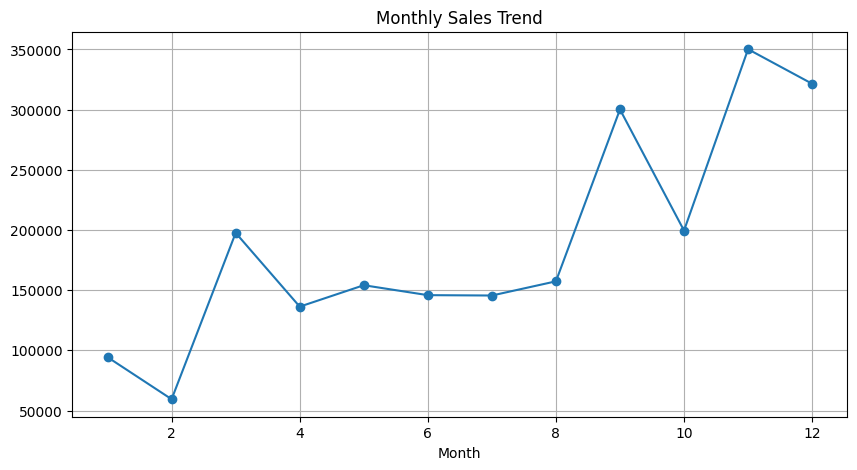

In [ ]:
# -----------------------------
# 12. Monthly Sales
# -----------------------------
if target_col and 'Month' in df.columns:

    monthly_sales = df.groupby('Month')[target_col].sum()

    plt.figure(figsize=(10,5))

    monthly_sales.plot(marker='o')

    plt.title("Monthly Sales Trend")

    plt.grid(True)

    plt.show()

# 13. Sales by Category

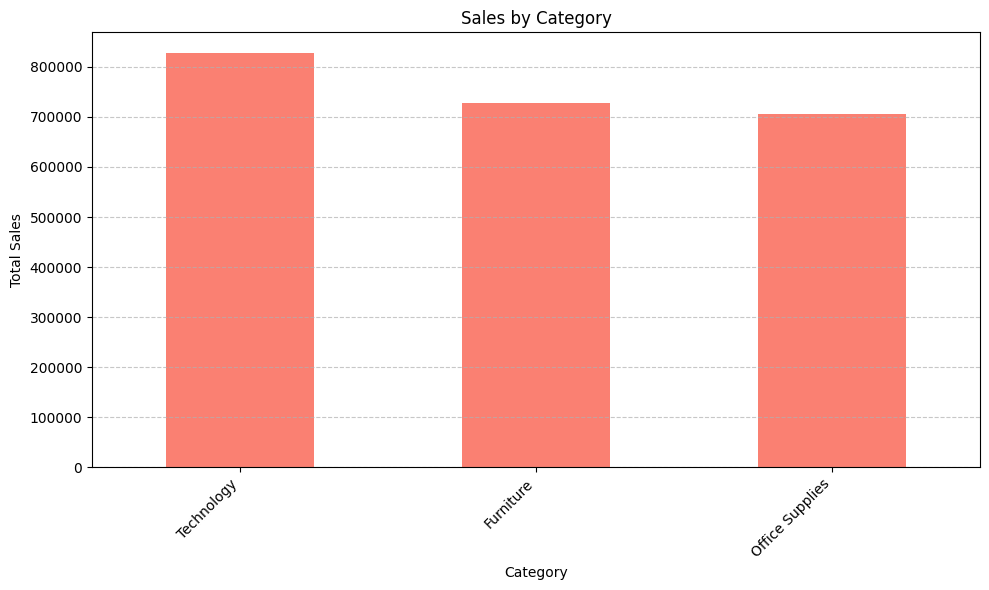

In [ ]:
if 'Category' in df.columns and target_col:
    sales_by_category = df.groupby('Category')[target_col].sum().sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sales_by_category.plot(kind='bar', color='salmon')
    plt.title('Sales by Category')
    plt.xlabel('Category')
    plt.ylabel(f'Total {target_col}')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'Category' column not found or target_col is not defined for sales by category analysis.")

# 14. Yearly Sales Trend

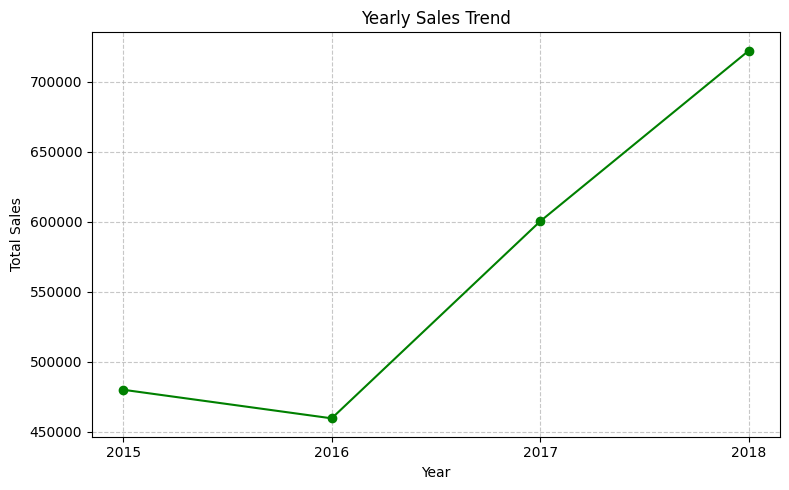

In [ ]:
if 'Year' in df.columns and target_col:
    yearly_sales = df.groupby('Year')[target_col].sum()

    plt.figure(figsize=(8, 5))
    yearly_sales.plot(kind='line', marker='o', color='green')
    plt.title('Yearly Sales Trend')
    plt.xlabel('Year')
    plt.ylabel(f'Total {target_col}')
    plt.xticks(yearly_sales.index)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'Year' column not found or target_col is not defined for yearly sales analysis.")

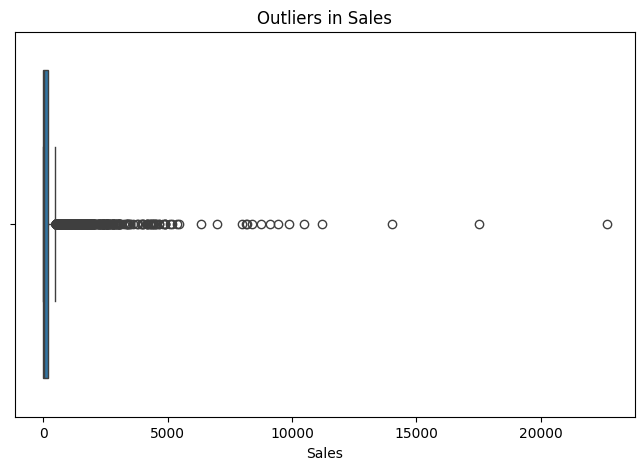

In [ ]:
# -----------------------------
# 13. Boxplot for Outliers
# -----------------------------
if target_col:

    plt.figure(figsize=(8,5))

    sns.boxplot(x=df[target_col])

    plt.title(f"Outliers in {target_col}")

    plt.show()


# 15. Handling Missing Values

In [ ]:
# Identify columns with missing values
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

print("Columns with missing values before filling:")
print(missing_cols)

# Fill missing 'Postal Code' values with 'Unknown'
# Since 'Postal Code' is numeric, filling with a string 'Unknown' will change its dtype to object.
# If numerical imputation is preferred, other methods like mean/median imputation should be used.
if 'Postal Code' in df.columns:
    df['Postal Code'] = df['Postal Code'].fillna('Unknown')

print("\nMissing values after filling:")
print(df.isnull().sum())

# Display info to show the change in dtype for 'Postal Code' if applicable
print("\nUpdated DataFrame Info:")
print(df.info())

Columns with missing values before filling:
Postal Code    11
dtype: int64

Missing values after filling:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
Day              0
dtype: int64

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object  

# 16. Outlier Removal using Quartiles

In [ ]:
if target_col in df.columns:
    # Calculate Q1, Q3, and IQR for the target column
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"Q1 for {target_col}: {Q1}")
    print(f"Q3 for {target_col}: {Q3}")
    print(f"IQR for {target_col}: {IQR}")
    print(f"Lower Bound for Outliers: {lower_bound}")
    print(f"Upper Bound for Outliers: {upper_bound}")
    # Identify outliers
    outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
    print(f"\nNumber of outliers identified in {target_col}: {len(outliers)}")
    print("Outlier details (first 5):")
    display(outliers.head())

    # Remove outliers from the DataFrame
    df_cleaned = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

    print(f"\nOriginal DataFrame shape: {df.shape}")
    print(f"DataFrame shape after outlier removal: {df_cleaned.shape}")

    # Update the main DataFrame 'df' with the cleaned data
    df = df_cleaned.copy()
    print("DataFrame updated with outliers removed.")
else:
    print(f"Error: Target column '{target_col}' not found for outlier removal.")

Q1 for Sales: 17.248
Q3 for Sales: 210.60500000000002
IQR for Sales: 193.35700000000003
Lower Bound for Outliers: -272.7875000000001
Upper Bound for Outliers: 500.6405000000001

Number of outliers identified in Sales: 1145
Outlier details (first 5):


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Day
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,8
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,11
7,8,CA-2015-115812,2015-06-09,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,2015,6,9
10,11,CA-2015-115812,2015-06-09,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,2015,6,9
11,12,CA-2015-115812,2015-06-09,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032.0,West,TEC-PH-10002033,Technology,Phones,Konftel 250 Conference phone - Charcoal black,911.4240,2015,6,9



Original DataFrame shape: (9800, 21)
DataFrame shape after outlier removal: (8655, 21)
DataFrame updated with outliers removed.


Now that outliers have been removed, let's re-check the distribution of the target variable.

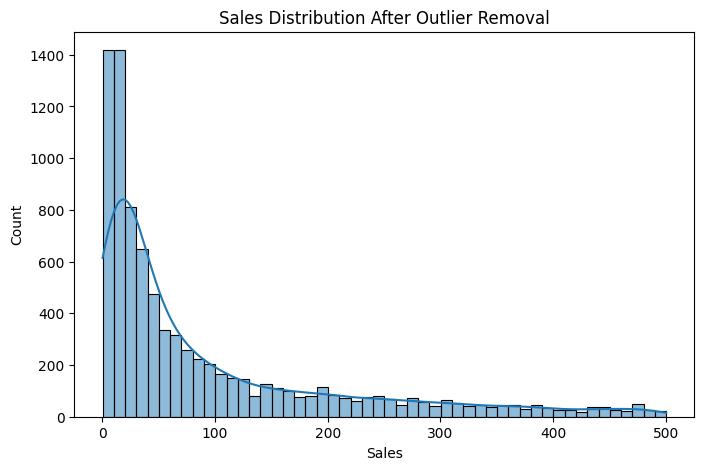

In [ ]:
if target_col:
    plt.figure(figsize=(8,5))

    sns.histplot(df[target_col], bins=50, kde=True)

    plt.title(f"{target_col} Distribution After Outlier Removal")
    plt.show()
else:
    print("Error: Target column not defined for distribution plot.")

# 17. Robust Scaling of Numerical Features

In [ ]:
from sklearn.preprocessing import RobustScaler

# Identify numerical columns for scaling
# Exclude 'Row ID' as it's an identifier and any non-numeric columns like 'Postal Code' if it became object type.
# 'Order Date' is datetime and handled separately.

# Get all numerical columns first
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude 'Row ID' from scaling
if 'Row ID' in numerical_cols:
    numerical_cols.remove('Row ID')

# Exclude 'Year', 'Month', 'Day' if you prefer not to scale them with RobustScaler,
# or keep them if they are considered continuous features for your model.
# For now, let's include them in robust scaling as they are numeric and can benefit.

print(f"Numerical columns to be scaled: {numerical_cols}")

# Initialize RobustScaler
scaler = RobustScaler()

# Apply Robust Scaling to the selected numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("\nDataFrame after Robust Scaling (first 5 rows of scaled columns):")
display(df[numerical_cols].head())

print("\nStatistical summary of scaled numerical columns:")
display(df[numerical_cols].describe())

Numerical columns to be scaled: ['Sales', 'Year', 'Month', 'Day']

DataFrame after Robust Scaling (first 5 rows of scaled columns):


,Sales,Year,Month,Day
0,2.021432,0.0,0.333333,-0.466667
2,-0.240107,0.0,-0.500000,-0.200000
4,-0.169263,-0.5,0.166667,-0.266667
5,0.072965,-1.0,-0.500000,-0.400000
6,-0.307220,-1.0,-0.500000,-0.400000



Statistical summary of scaled numerical columns:


,Sales,Year,Month,Day
count,8655.000000,8655.000000,8655.000000,8655.000000
mean,0.478507,-0.132756,-0.201078,0.029732
std,1.048692,0.561347,0.547602,0.583478
min,-0.369724,-1.000000,-1.333333,-0.933333
25%,-0.236504,-0.500000,-0.666667,-0.466667
50%,0.000000,0.000000,0.000000,0.000000
75%,0.763496,0.500000,0.333333,0.533333
max,4.200132,0.500000,0.500000,1.066667


# 18. Feature Engineering: Encoding Categorical and Time-Based Features

### Extract Day of Week

In [ ]:
if 'Order Date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Order Date']):
    df['DayOfWeek'] = df['Order Date'].dt.dayofweek
    print("Added 'DayOfWeek' column:")
    display(df[['Order Date', 'DayOfWeek']].head())
else:
    print("Order Date column not found or not in datetime format. Skipping DayOfWeek extraction.")

Added 'DayOfWeek' column:


,Order Date,DayOfWeek
0,2017-11-08,2
2,2017-06-12,0
4,2016-10-11,1
5,2015-06-09,1
6,2015-06-09,1


### Frequency Encoding

In [ ]:
frequency_cols = ['City', 'Category', 'Product Name']

for col in frequency_cols:
    if col in df.columns:
        # Calculate frequency
        freq_map = df[col].value_counts(normalize=True)
        # Create new column for frequency encoding
        df[f'{col}_Freq'] = df[col].map(freq_map)
        print(f"Frequency encoded '{col}' into '{col}_Freq'. First 5 rows:")
        display(df[[col, f'{col}_Freq']].head())
    else:
        print(f"Column '{col}' not found for frequency encoding.")

Frequency encoded 'City' into 'City_Freq'. First 5 rows:


,City,City_Freq
0,Henderson,0.004506
2,Los Angeles,0.073368
4,Fort Lauderdale,0.000924
5,Los Angeles,0.073368
6,Los Angeles,0.073368


Frequency encoded 'Category' into 'Category_Freq'. First 5 rows:


,Category,Category_Freq
0,Furniture,0.187060
2,Office Supplies,0.648989
4,Office Supplies,0.648989
5,Furniture,0.187060
6,Office Supplies,0.648989


Frequency encoded 'Product Name' into 'Product Name_Freq'. First 5 rows:


,Product Name,Product Name_Freq
0,Bush Somerset Collection Bookcase,0.000347
2,Self-Adhesive Address Labels for Typewriters b...,0.000809
4,Eldon Fold 'N Roll Cart System,0.000578
5,Eldon Expressions Wood and Plastic Desk Access...,0.000578
6,Newell 322,0.000693


### One-Hot Encoding

In [ ]:
onehot_col = 'Category'

if onehot_col in df.columns:
    # Perform one-hot encoding
    df = pd.get_dummies(df, columns=[onehot_col], prefix=onehot_col, drop_first=True)
    print(f"One-hot encoded '{onehot_col}'. First 5 rows of new columns:")
    # Display the new one-hot encoded columns and the original category for context
    display(df[[col for col in df.columns if col.startswith(f'{onehot_col}_')]].head())
else:
    print(f"Column '{onehot_col}' not found for one-hot encoding.")

One-hot encoded 'Category'. First 5 rows of new columns:


,Category_Freq,Category_Office Supplies,Category_Technology
0,0.187060,False,False
2,0.648989,True,False
4,0.648989,True,False
5,0.187060,False,False
6,0.648989,True,False


### Cyclical Encoding

In [ ]:
cyclical_cols = ['Month', 'DayOfWeek']

for col in cyclical_cols:
    if col in df.columns:
        # Max value for the cycle (e.g., 12 for month, 7 for day of week)
        if col == 'Month':
            max_val = 12
        elif col == 'DayOfWeek':
            max_val = 7
        else:
            print(f"Max value for cyclical encoding not defined for '{col}'. Skipping.")
            continue

        df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / max_val)
        df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / max_val)
        print(f"Cyclically encoded '{col}' into '{col}_sin' and '{col}_cos'. First 5 rows:")
        display(df[[col, f'{col}_sin', f'{col}_cos']].head())
    else:
        print(f"Column '{col}' not found for cyclical encoding.")

print("\nDataFrame info after all encodings:")
df.info()

Cyclically encoded 'Month' into 'Month_sin' and 'Month_cos'. First 5 rows:


,Month,Month_sin,Month_cos
0,0.333333,0.173648,0.984808
2,-0.500000,-0.258819,0.965926
4,0.166667,0.087156,0.996195
5,-0.500000,-0.258819,0.965926
6,-0.500000,-0.258819,0.965926


Cyclically encoded 'DayOfWeek' into 'DayOfWeek_sin' and 'DayOfWeek_cos'. First 5 rows:


,DayOfWeek,DayOfWeek_sin,DayOfWeek_cos
0,2,0.974928,-0.222521
2,0,0.000000,1.000000
4,1,0.781831,0.623490
5,1,0.781831,0.623490
6,1,0.781831,0.623490



DataFrame info after all encodings:
<class 'pandas.core.frame.DataFrame'>
Index: 8655 entries, 0 to 9799
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Row ID                    8655 non-null   int64         
 1   Order ID                  8655 non-null   object        
 2   Order Date                8655 non-null   datetime64[ns]
 3   Ship Date                 8655 non-null   object        
 4   Ship Mode                 8655 non-null   object        
 5   Customer ID               8655 non-null   object        
 6   Customer Name             8655 non-null   object        
 7   Segment                   8655 non-null   object        
 8   Country                   8655 non-null   object        
 9   City                      8655 non-null   object        
 10  State                     8655 non-null   object        
 11  Postal Code               8655 non-null   object  

## Rolling Window Analysis: Sales Rolling Mean

In [ ]:
if 'Order Date' in df.columns and pd.api.types.is_datetime64_any_dtype(df['Order Date']):
    # Sort by 'Order Date' to ensure correct rolling window calculation
    df_sorted = df.sort_values(by='Order Date')

    # Calculate a 7-day rolling mean of 'Sales'
    # min_periods=1 allows the rolling mean to be calculated even if there are fewer than 7 days of data
    df_sorted['Sales_RollingMean_7D'] = df_sorted['Sales'].rolling(window=7, min_periods=1).mean()

    print("DataFrame with 7-day rolling mean of Sales (first 10 rows):")
    display(df_sorted[['Order Date', 'Sales', 'Sales_RollingMean_7D']].head(10))

    # Optionally, update the original df with the new column and sorted order if desired
    df = df_sorted.copy() # Uncomment this line if you want to update the main df
else:
    print("Error: 'Order Date' column not found or not in datetime format. Cannot perform rolling mean.")

DataFrame with 7-day rolling mean of Sales (first 10 rows):


,Order Date,Sales,Sales_RollingMean_7D
7980,2015-01-03,-0.223393,-0.223393
739,2015-01-04,-0.266038,-0.244715
740,2015-01-04,2.119962,0.543511
741,2015-01-04,-0.341416,0.322279
1759,2015-01-05,-0.195158,0.218792
7476,2015-01-06,-0.323678,0.128380
7180,2015-01-06,-0.256931,0.073336
7477,2015-01-06,3.210263,0.563858
5327,2015-01-06,-0.196035,0.573858
7479,2015-01-06,-0.089240,0.258258


## Displaying Year Values

In [ ]:
if 'Year' in df.columns:
    print("Unique Year values:")
    display(df['Year'].unique())
else:
    print("'Year' column not found in the DataFrame.")

Unique Year values:


array([-1. , -0.5,  0. ,  0.5])

### Original Year Values (before scaling)

In [ ]:
if 'Year' in df_cleaned.columns:
    print("Unique original (unscaled) Year values:")
    display(df_cleaned['Year'].unique())
else:
    print("'Year' column not found in the original DataFrame before scaling (df_cleaned).")

Unique original (unscaled) Year values:


array([2017, 2016, 2015, 2018], dtype=int32)

## Feature Engineering: Lag and Rolling Window Features

In [ ]:
# Ensure the DataFrame is sorted by 'Order Date' for correct time-series operations
# The DataFrame 'df' should already be sorted from the previous rolling mean calculation.
# If not, uncomment the line below:
# df = df.sort_values(by='Order Date').reset_index(drop=True)

# 1. Lag Feature for a Year (365 days)
# We assume a daily frequency. For more complex time series, resample first.
# Using `groupby()` on an identifier like `Product ID` or `Customer ID` might be necessary
# if the lag needs to be specific to each product/customer.
# For now, applying a global lag based on the sorted 'Order Date'.
if 'Sales' in df.columns and 'Order Date' in df.columns:
    df['Sales_Lag_90D'] = df['Sales'].shift(periods=90)
    print("Added 'Sales_Lag_90D' (3-month lag).")
else:
    print("Error: 'Sales' or 'Order Date' column not found for lag feature.")

# 2. Rolling Mean for a Week (7 days)
# This was calculated previously, but re-calculating to ensure it's based on the most recent df state.
if 'Sales' in df.columns:
    df['Sales_RollingMean_7D'] = df['Sales'].rolling(window=7, min_periods=1).mean()
    print("Added/Updated 'Sales_RollingMean_7D' (7-day rolling mean).")
else:
    print("Error: 'Sales' column not found for 7-day rolling mean.")

# 3. Rolling Standard Deviation for a Month (approx. 30 days)
if 'Sales' in df.columns and 'Order Date' in df.columns:

    # 6-month lag feature (approximately 180 days)
    df['Sales_Lag_180D'] = df['Sales'].shift(periods=180)

    # 6-month rolling standard deviation
    df['Sales_RollingStd_180D'] = df['Sales'].rolling(
        window=180,
        min_periods=1
    ).std()

    print("Added 'Sales_Lag_180D' (6-month lag).")
    print("Added 'Sales_RollingStd_180D' (6-month rolling standard deviation).")

else:
    print("Error: 'Sales' or 'Order Date' column not found.")

print("\nDataFrame with new lag and rolling features (first 10 rows):")

display(
    df[
        [
            'Order Date',
            'Sales',
            'Sales_Lag_180D',
            'Sales_RollingMean_7D',
            'Sales_RollingStd_180D'
        ]
    ].head(10)
)


Added 'Sales_Lag_90D' (3-month lag).
Added/Updated 'Sales_RollingMean_7D' (7-day rolling mean).
Added 'Sales_Lag_180D' (6-month lag).
Added 'Sales_RollingStd_180D' (6-month rolling standard deviation).

DataFrame with new lag and rolling features (first 10 rows):


,Order Date,Sales,Sales_Lag_180D,Sales_RollingMean_7D,Sales_RollingStd_180D
7980,2015-01-03,-0.223393,NaN,-0.223393,NaN
739,2015-01-04,-0.266038,NaN,-0.244715,0.030155
740,2015-01-04,2.119962,NaN,0.543511,1.365413
741,2015-01-04,-0.341416,NaN,0.322279,1.199448
1759,2015-01-05,-0.195158,NaN,0.218792,1.064216
7476,2015-01-06,-0.323678,NaN,0.128380,0.977287
7180,2015-01-06,-0.256931,NaN,0.073336,0.903945
7477,2015-01-06,3.210263,NaN,0.563858,1.389397
5327,2015-01-06,-0.196035,NaN,0.573858,1.318234
7479,2015-01-06,-0.089240,NaN,0.258258,1.252123


## Visualizing Lag and Rolling Feature Distributions

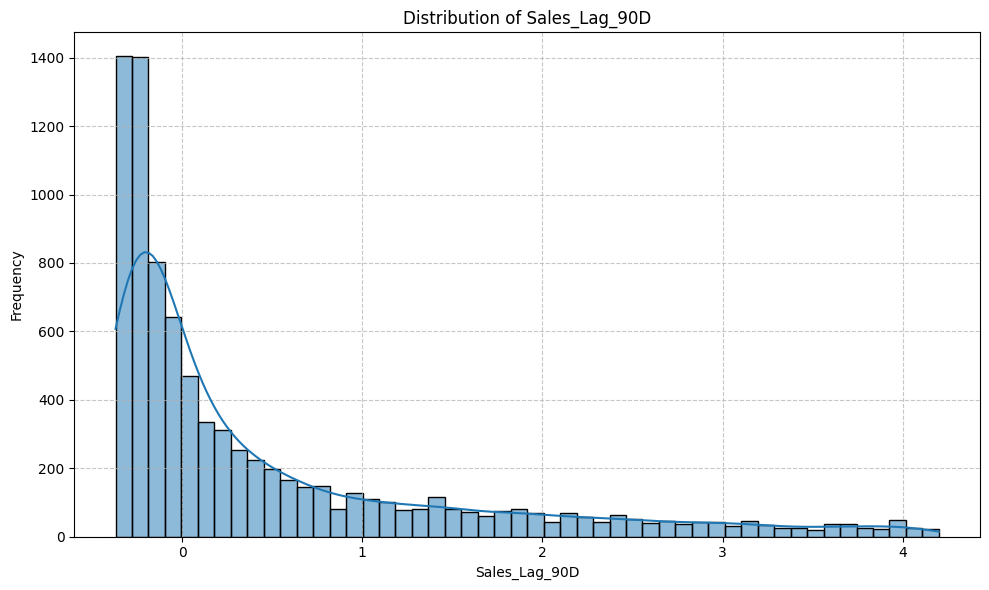

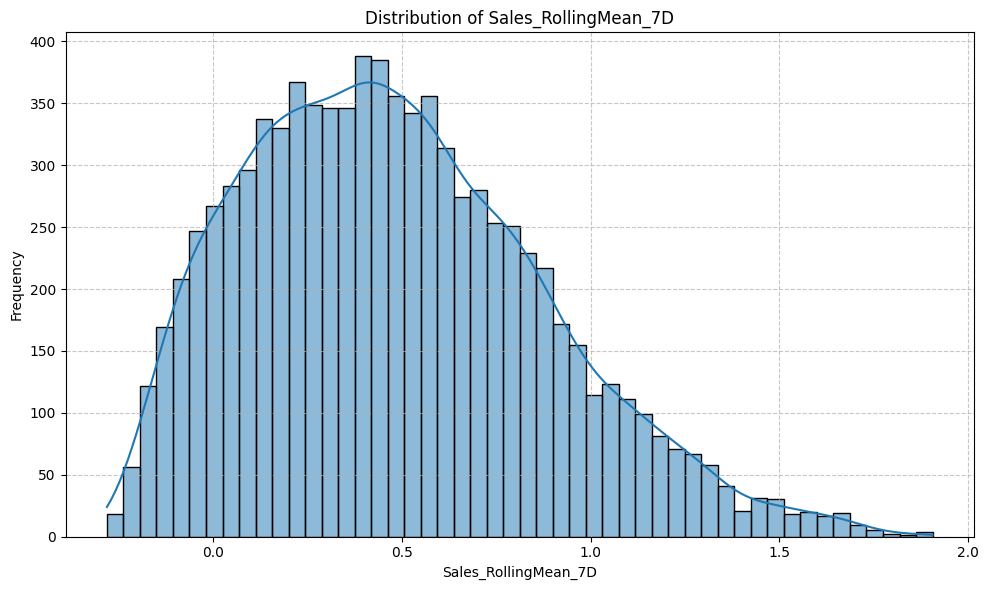

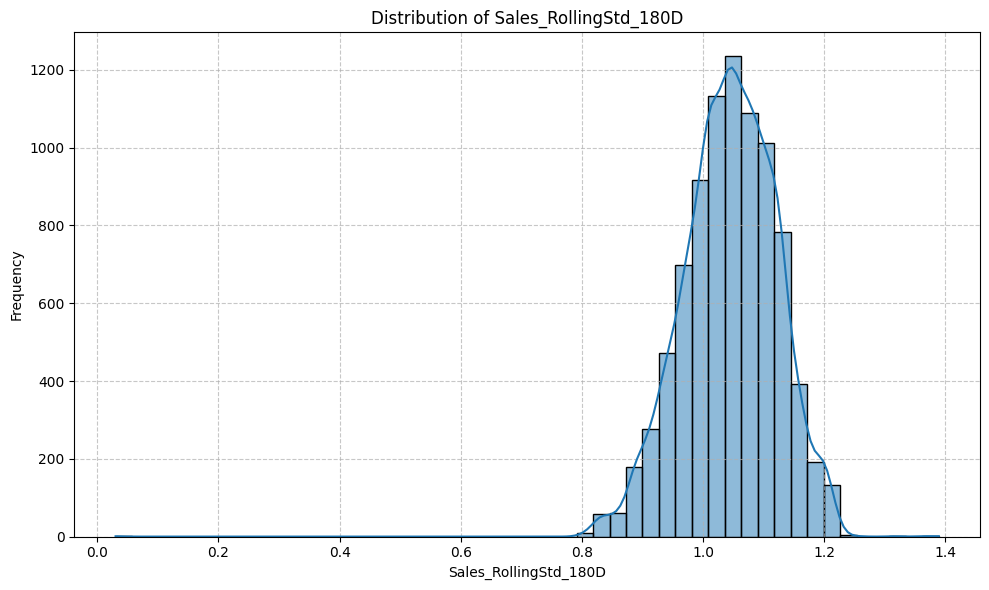

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of features to visualize
features_to_visualize = ['Sales_Lag_90D', 'Sales_RollingMean_7D', 'Sales_RollingStd_180D']

for feature in features_to_visualize:
    if feature in df.columns:
        plt.figure(figsize=(10, 6))
        sns.histplot(df[feature].dropna(), bins=50, kde=True) # Drop NaNs for visualization if any
        plt.title(f'Distribution of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Warning: Column '{feature}' not found in the DataFrame. Skipping visualization.")


## Preparing Data for Modeling: Train, Test, and Validation Split

## Preparing Data for Modeling: Train, Test, and Validation Split

In [ ]:
from sklearn.model_selection import train_test_split

# Identify the target variable
target_col = 'Sales'  # Already defined as 'Sales' previously

# Drop unnecessary columns that are identifiers, raw date fields, or already encoded.
# 'Category' was one-hot encoded, so the original 'Category' column can be dropped.
# 'Product Name', 'City' have frequency encoded versions.
# 'Month', 'Day', 'DayOfWeek' have cyclical encoded versions.
# 'Postal Code' was filled with 'Unknown' which makes it a mixed type, also not useful as numerical.
columns_to_drop = [
    'Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name',
    'Product ID', 'Product Name', 'City', 'State', 'Country', 'Region', 'Ship Mode',
    'Sub-Category', 'Postal Code', 'Category', 'Year', 'Month', 'Day', 'DayOfWeek'
]

# Ensure only existing columns are dropped
columns_to_drop_existing = [col for col in columns_to_drop if col in df.columns]

X = df.drop(columns=columns_to_drop_existing + [target_col])
y = df[target_col]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("\nFirst 5 rows of features (X):")
display(X.head())

Features (X) shape: (8655, 16)
Target (y) shape: (8655,)

First 5 rows of features (X):


,Segment,City_Freq,Category_Freq,Product Name_Freq,Category_Office Supplies,Category_Technology,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Sales_RollingMean_7D,Sales_Lag_365D,Sales_RollingStd_30D,Sales_Lag_90D,Sales_Lag_180D,Sales_RollingStd_180D
7980,Consumer,0.038937,0.648989,0.000693,True,False,-0.642788,0.766044,-0.974928,-0.222521,-0.223393,NaN,NaN,NaN,NaN,NaN
739,Home Office,0.000809,0.648989,0.000693,True,False,-0.642788,0.766044,-0.781831,0.623490,-0.244715,NaN,0.030155,NaN,NaN,0.030155
740,Home Office,0.000809,0.648989,0.000809,True,False,-0.642788,0.766044,-0.781831,0.623490,0.543511,NaN,1.365413,NaN,NaN,1.365413
741,Home Office,0.000809,0.648989,0.000578,True,False,-0.642788,0.766044,-0.781831,0.623490,0.322279,NaN,1.199448,NaN,NaN,1.199448
1759,Consumer,0.055113,0.648989,0.000693,True,False,-0.642788,0.766044,0.000000,1.000000,0.218792,NaN,1.064216,NaN,NaN,1.064216


In [ ]:
# Split data into training and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Further split the training data into training and validation sets (e.g., 80% train, 20% validation from the original 80% train)
# This means X_train_full will be split again. The validation set will be 20% of the original training set, which is 0.2 * 0.8 = 0.16 (16%) of the total data.
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"X_train_final shape: {X_train_final.shape}")
print(f"y_train_final shape: {y_train_final.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train_final shape: (5539, 16)
y_train_final shape: (5539,)
X_val shape: (1385, 16)
y_val shape: (1385,)
X_test shape: (1731, 16)
y_test shape: (1731,)


## Model Training: XGBoost Regressor

## Hyperparameter Tuning with RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import pandas as pd

# Check for and handle 'object' type columns again before RandomizedSearchCV
# This is a safeguard in case the previous one-hot encoding was not fully effective
# or if the dataframes were inadvertently reset.

# Ensure X_train_final, X_val, X_test are DataFrames
if not isinstance(X_train_final, pd.DataFrame):
    X_train_final = pd.DataFrame(X_train_final)
if not isinstance(X_val, pd.DataFrame):
    X_val = pd.DataFrame(X_val)
if not isinstance(X_test, pd.DataFrame):
    X_test = pd.DataFrame(X_test)

categorical_cols_for_xgb = X_train_final.select_dtypes(include='object').columns

if len(categorical_cols_for_xgb) > 0:
    print(f"Re-applying one-hot encoding for columns: {list(categorical_cols_for_xgb)}")
    X_train_final = pd.get_dummies(X_train_final, columns=categorical_cols_for_xgb, drop_first=True)
    X_val = pd.get_dummies(X_val, columns=categorical_cols_for_xgb, drop_first=True)
    X_test = pd.get_dummies(X_test, columns=categorical_cols_for_xgb, drop_first=True)
    print("One-hot encoding re-applied.")
else:
    print("No 'object' type columns found in X_train_final for re-encoding.")

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 1000),  # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3),  # Step size shrinkage
    'max_depth': randint(3, 10),         # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4),      # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5),            # Minimum loss reduction required to make a further partition
    'min_child_weight': randint(1, 10)   # Minimum sum of instance weight (hessian) needed in a child
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled
# cv: Number of cross-validation folds
# verbose: Controls the verbosity: the higher, the more messages
# random_state: Seed for reproducibility
# n_jobs: Number of jobs to run in parallel (-1 means using all processors)
random_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_distributions=param_dist,
    n_iter=50, # You can increase this for a more thorough search
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Using negative MSE to maximize (Scikit-learn convention)
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

print("Starting RandomizedSearchCV for hyperparameter tuning...")
random_search.fit(X_train_final, y_train_final)
print("RandomizedSearchCV complete.")

# Print the best parameters and best score
print("\nBest Hyperparameters found:", random_search.best_params_)
print("Best MSE (negative, so smaller magnitude is better):", -random_search.best_score_)

# Get the best model
best_xgb_model = random_search.best_estimator_


Re-applying one-hot encoding for columns: ['Segment']
One-hot encoding re-applied.
Starting RandomizedSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV complete.

Best Hyperparameters found: {'colsample_bytree': np.float64(0.9022204554172195), 'gamma': np.float64(0.11439908274581123), 'learning_rate': np.float64(0.0330939729486379), 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 185, 'subsample': np.float64(0.9521871356061031)}
Best MSE (negative, so smaller magnitude is better): 0.8009129646250237


### Evaluating the Tuned XGBoost Model

Mean Absolute Error (MAE) for Tuned Model: 0.6276
Mean Squared Error (MSE) for Tuned Model: 0.8006
Root Mean Squared Error (RMSE) for Tuned Model: 0.8948
R-squared (R2) for Tuned Model: 0.2836


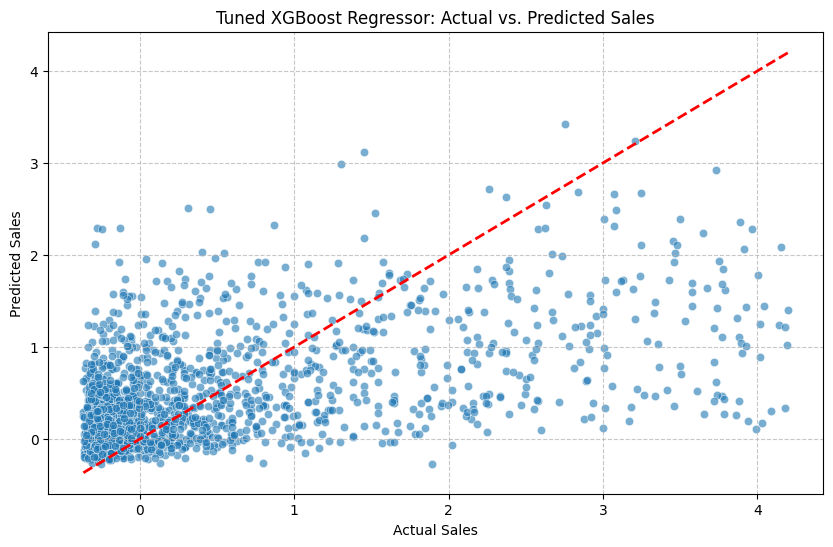

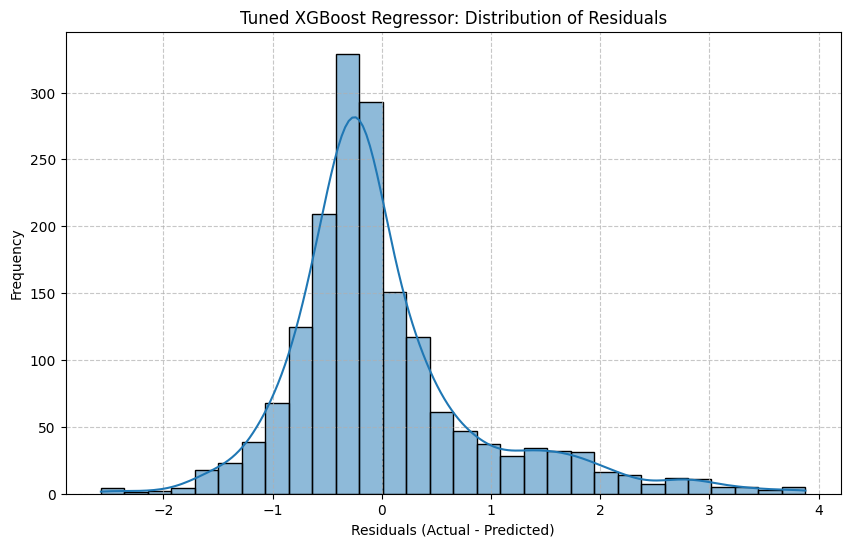

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set using the best model
y_pred_tuned = best_xgb_model.predict(X_test)

# Calculate evaluation metrics for the tuned model
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Mean Absolute Error (MAE) for Tuned Model: {mae_tuned:.4f}")
print(f"Mean Squared Error (MSE) for Tuned Model: {mse_tuned:.4f}")
print(f"Root Mean Squared Error (RMSE) for Tuned Model: {rmse_tuned:.4f}")
print(f"R-squared (R2) for Tuned Model: {r2_tuned:.4f}")

# Plotting actual vs. predicted values for the tuned model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Tuned XGBoost Regressor: Actual vs. Predicted Sales")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plotting residuals for the tuned model
residuals_tuned = y_test - y_pred_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals_tuned, kde=True, bins=30)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Tuned XGBoost Regressor: Distribution of Residuals")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## Model Training: Linear Regression

Checking for and handling NaN values in feature sets for Linear Regression...
NaNs found in training features: ['Sales_Lag_365D', 'Sales_RollingStd_30D', 'Sales_Lag_90D', 'Sales_Lag_180D', 'Sales_RollingStd_180D']
NaNs found in validation features: ['Sales_Lag_365D', 'Sales_Lag_90D', 'Sales_Lag_180D']
NaNs found in test features: ['Sales_Lag_365D', 'Sales_Lag_90D', 'Sales_Lag_180D']
NaN values imputed with column means.
Initializing and training Linear Regression model...
Linear Regression model training complete.

--- Linear Regression Model Performance ---
Mean Absolute Error (MAE) for LR Model: 0.6575
Mean Squared Error (MSE) for LR Model: 0.8210
Root Mean Squared Error (RMSE) for LR Model: 0.9061
R-squared (R2) for LR Model: 0.2654


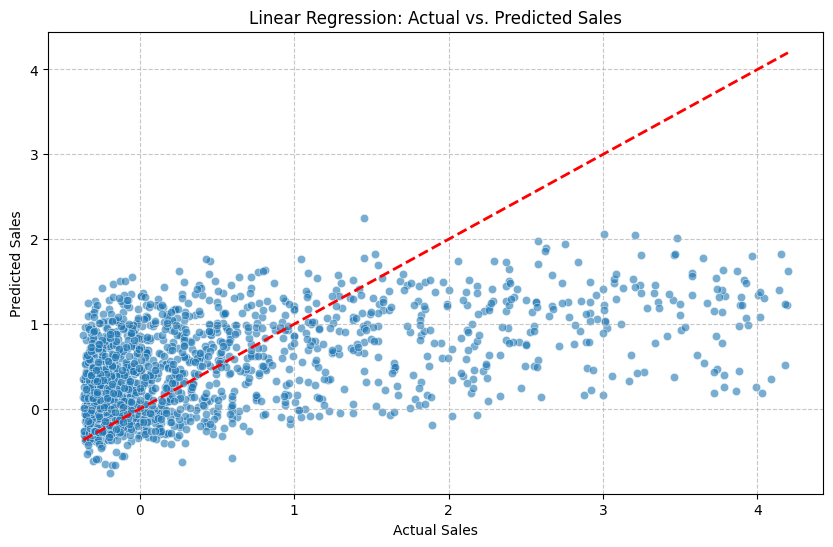

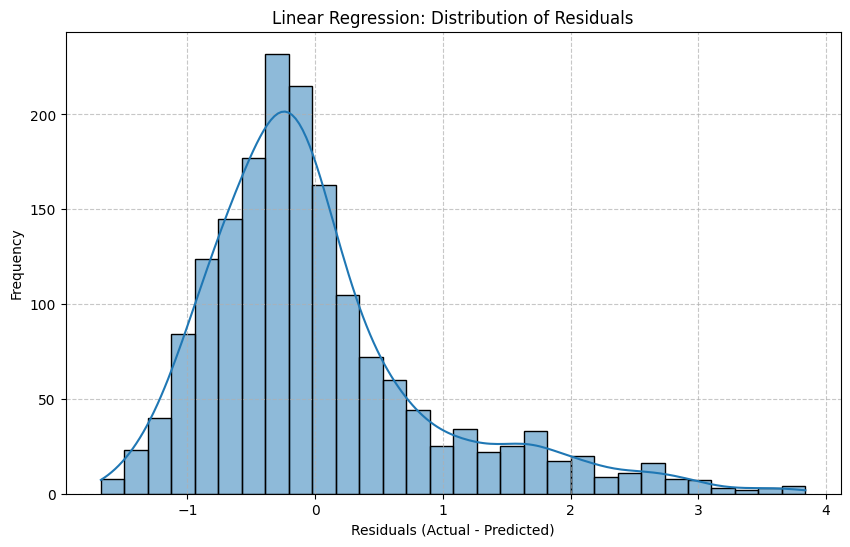

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for DataFrame operations

print("Checking for and handling NaN values in feature sets for Linear Regression...")

# Convert to DataFrame if not already (important for .fillna to work on columns)
X_train_final = pd.DataFrame(X_train_final)
X_val = pd.DataFrame(X_val)
X_test = pd.DataFrame(X_test)

# Identify columns with NaN values (likely from lag/rolling features)
nan_cols_train = X_train_final.columns[X_train_final.isnull().any()].tolist()
nan_cols_val = X_val.columns[X_val.isnull().any()].tolist()
nan_cols_test = X_test.columns[X_test.isnull().any()].tolist()

if nan_cols_train or nan_cols_val or nan_cols_test:
    print(f"NaNs found in training features: {nan_cols_train}")
    print(f"NaNs found in validation features: {nan_cols_val}")
    print(f"NaNs found in test features: {nan_cols_test}")

    # Impute NaNs using the mean of each column from the training set
    # It's important to fit the imputer on training data only and transform all sets.
    for col in nan_cols_train:
        if col in X_train_final.columns:
            mean_value = X_train_final[col].mean()
            X_train_final[col] = X_train_final[col].fillna(mean_value)
            # Apply the same mean to validation and test sets
            if col in X_val.columns:
                X_val[col] = X_val[col].fillna(mean_value)
            if col in X_test.columns:
                X_test[col] = X_test[col].fillna(mean_value)
    print("NaN values imputed with column means.")
else:
    print("No NaN values found in feature sets.")


print("Initializing and training Linear Regression model...")

# Initialize Linear Regression model
linear_model = LinearRegression()

# Fit the model to the training data
linear_model.fit(X_train_final, y_train_final)

print("Linear Regression model training complete.")

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Calculate evaluation metrics for the Linear Regression model
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"\n--- Linear Regression Model Performance ---")
print(f"Mean Absolute Error (MAE) for LR Model: {mae_lr:.4f}")
print(f"Mean Squared Error (MSE) for LR Model: {mse_lr:.4f}")
print(f"Root Mean Squared Error (RMSE) for LR Model: {rmse_lr:.4f}")
print(f"R-squared (R2) for LR Model: {r2_lr:.4f}")

# Plotting actual vs. predicted values for the Linear Regression model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Linear Regression: Actual vs. Predicted Sales")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plotting residuals for the Linear Regression model
residuals_lr = y_test - y_pred_lr
plt.figure(figsize=(10, 6))
sns.histplot(residuals_lr, kde=True, bins=30)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Linear Regression: Distribution of Residuals")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


## Model Training: Random Forest Regressor

Initializing and training Random Forest Regressor model...
Random Forest Regressor model training complete.

--- Random Forest Regressor Model Performance ---
Mean Absolute Error (MAE) for RF Model: 0.6528
Mean Squared Error (MSE) for RF Model: 0.8387
Root Mean Squared Error (RMSE) for RF Model: 0.9158
R-squared (R2) for RF Model: 0.2496


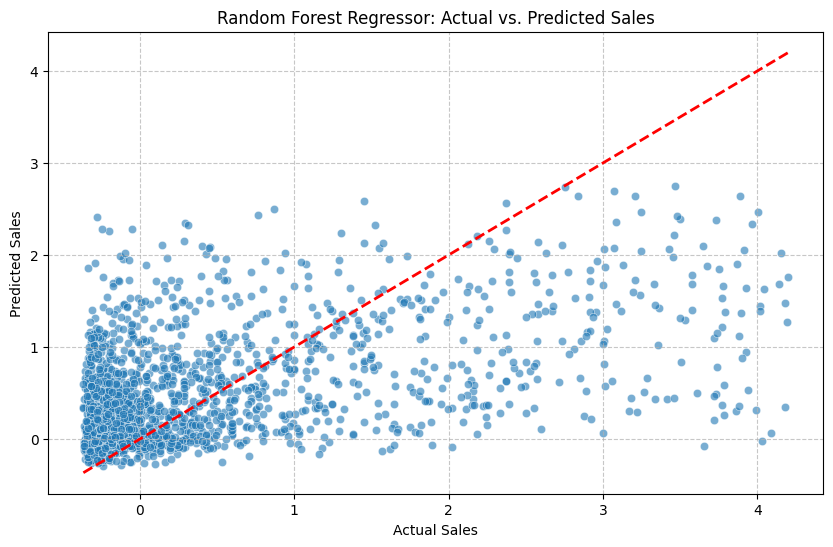

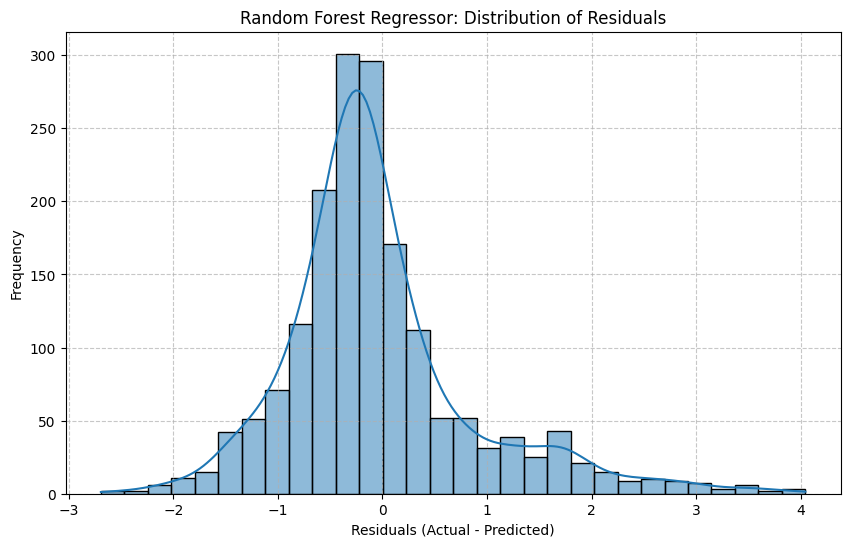

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Initializing and training Random Forest Regressor model...")

# Initialize Random Forest Regressor model
# You can tune hyperparameters (e.g., n_estimators, max_depth) as needed
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the model to the training data
rf_model.fit(X_train_final, y_train_final)

print("Random Forest Regressor model training complete.")

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics for the Random Forest Regressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n--- Random Forest Regressor Model Performance ---")
print(f"Mean Absolute Error (MAE) for RF Model: {mae_rf:.4f}")
print(f"Mean Squared Error (MSE) for RF Model: {mse_rf:.4f}")
print(f"Root Mean Squared Error (RMSE) for RF Model: {rmse_rf:.4f}")
print(f"R-squared (R2) for RF Model: {r2_rf:.4f}")

# Plotting actual vs. predicted values for the Random Forest Regressor model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest Regressor: Actual vs. Predicted Sales")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plotting residuals for the Random Forest Regressor model
residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(10, 6))
sns.histplot(residuals_rf, kde=True, bins=30)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Random Forest Regressor: Distribution of Residuals")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Hyperparameter Tuning (Random Forest with RandomizedSearchCV)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

print("Starting RandomizedSearchCV for Random Forest Regressor hyperparameter tuning...")

# Define the parameter distribution for RandomizedSearchCV
param_dist_rf = {
    'n_estimators': randint(100, 500), # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'], # Number of features to consider when looking for the best split
    'max_depth': randint(10, 100),       # Maximum number of levels in tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10),  # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]           # Method of selecting samples for training each tree
}

# Initialize RandomizedSearchCV for Random Forest
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=50, # Number of parameter settings that are sampled. Increase for more thorough search
    cv=5,       # 5-fold cross-validation
    scoring='neg_mean_squared_error', # Using negative MSE to maximize (Scikit-learn convention)
    verbose=1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

random_search_rf.fit(X_train_final, y_train_final)
print("RandomizedSearchCV for Random Forest complete.")

# Print the best parameters and best score
print("\nBest Hyperparameters found for Random Forest:", random_search_rf.best_params_)
print("Best MSE (negative, so smaller magnitude is better) for Random Forest:", -random_search_rf.best_score_)

# Get the best model
best_rf_model = random_search_rf.best_estimator_

Starting RandomizedSearchCV for Random Forest Regressor hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

### Evaluating the Tuned Random Forest Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set using the best Random Forest model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics for the tuned Random Forest model
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"\n--- Tuned Random Forest Model Performance ---")
print(f"Mean Absolute Error (MAE) for Tuned RF Model: {mae_tuned_rf:.4f}")
print(f"Mean Squared Error (MSE) for Tuned RF Model: {mse_tuned_rf:.4f}")
print(f"Root Mean Squared Error (RMSE) for Tuned RF Model: {rmse_tuned_rf:.4f}")
print(f"R-squared (R2) for Tuned RF Model: {r2_tuned_rf:.4f}")

# Plotting actual vs. predicted values for the tuned Random Forest model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_tuned_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Tuned Random Forest Regressor: Actual vs. Predicted Sales")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plotting residuals for the tuned Random Forest model
residuals_tuned_rf = y_test - y_pred_tuned_rf
plt.figure(figsize=(10, 6))
sns.histplot(residuals_tuned_rf, kde=True, bins=30)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Tuned Random Forest Regressor: Distribution of Residuals")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()